In [1]:
import matplotlib.pyplot as plt
from matplotlib import rc, rcParams
import matplotlib.cm as cm
from types import SimpleNamespace
import numpy as np
import matplotlib.colors as mcolors
import math

try:
    from scipy.integrate import trapezoid, cumulative_trapezoid
except ImportError:
    from scipy.integrate import trapz as trapezoid
    from scipy.integrate import cumtrapz as cumulative_trapezoid

from scipy.optimize import fsolve
from scipy.ndimage import gaussian_filter1d
from scipy.signal import savgol_filter
from matplotlib.ticker import LogLocator, LogFormatter, LogFormatterMathtext, FixedLocator, FixedFormatter, MultipleLocator, NullFormatter
import matplotlib.ticker as ticker
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import os
import sys
sys.stderr = open(os.devnull, 'w')

paper_mode=False

if paper_mode:
    fontsize_global=30 # 30
    rc('text', usetex=True)  # switch to True for latex font (might be slow)
    rcParams.update({
        "xtick.major.size": 8, "xtick.minor.size": 4, "ytick.major.size": 8, "ytick.minor.size": 4,
        'xtick.direction': 'in', 'ytick.direction': 'in', 'xtick.top': True, 'ytick.right': True,
        'font.size': fontsize_global,    'axes.labelsize': fontsize_global, 'xtick.labelsize': fontsize_global, 'ytick.labelsize': fontsize_global,
        'axes.grid': False, 'grid.alpha': 0.3,'axes.linewidth': 2.3, 'xtick.major.width': 2.3,  # Major tick width on x-axis
        'xtick.minor.width': 1.0,  # Minor tick width on x-axis
        'ytick.major.width': 2.3,  # Major tick width on y-axis
        'ytick.minor.width': 1.0})

    plt.rcParams.update({
        'text.usetex': True,               # Use LaTeX for typesetting
        'font.family': 'serif',
        'font.serif': ['Helvetica'],  # Use the same serif font as MATLAB
        'axes.unicode_minus': False        # To ensure minus sign renders correctly
    })
else:
    fontsize_global=20
    rc('text', usetex=True)  # switch to True for latex font (might be slow)
    rcParams.update({
        "xtick.major.size": 6, "xtick.minor.size": 3, "ytick.major.size": 6, "ytick.minor.size": 3,
        'xtick.direction': 'in', 'ytick.direction': 'in', 'xtick.top': True, 'ytick.right': True,
        'font.size': fontsize_global,    'axes.labelsize': fontsize_global, 'xtick.labelsize': fontsize_global, 'ytick.labelsize': fontsize_global,
        'axes.grid': False, 'grid.alpha': 0.3,'axes.linewidth': 2.0, 'xtick.major.width': 2.0,  # Major tick width on x-axis
        'xtick.minor.width': 1.0,  # Minor tick width on x-axis
        'ytick.major.width': 2.0,  # Major tick width on y-axis
        'ytick.minor.width': 1.0})
    rcParams['mathtext.fontset'] = 'stix'


from IPython.core.display import HTML
HTML('''
    <style>
        .container { 
            width: 95% !important;
        }
        .output_wrapper, .output {
            height: auto !important;
            max-height: none !important;
        }
    </style>
''')

<br>

# Load files
<br>

<hr style="border:0.5px solid black">

In [2]:
def setup_Tw(fol, params):
    Tw = SimpleNamespace()

    # Set dataset-specific parameters
    timestamp   = params['timestamp']
    Tw.Minf     = params['Minf']
    Tw.Prinf    = params['Prinf']
    Tw.Re_bulk  = params['Re_bulk']

    Tw.x = np.fromfile(f"{fol}/x.bin")
    Tw.y = np.fromfile(f"{fol}/y.bin")
    Tw.z = np.fromfile(f"{fol}/z.bin")

    Tw.imax = len(Tw.x)
    Tw.jmax = len(Tw.y)
    Tw.kmax = len(Tw.z)

    print(f'# Dataset: {fol}')
    print('#1: ' + str(Tw.imax))
    print(str(Tw.x[-1]))
    print('#################################################')

    # ------------------------------------------------------------------ #
    #  Reynolds averages                                                   #
    # ------------------------------------------------------------------ #
    Tw.t_avg    = np.fromfile(f"{fol}/t_avg.{timestamp:07d}.bin")
    Tw.w_avg    = np.fromfile(f"{fol}/w_avg.{timestamp:07d}.bin")
    Tw.u_avg    = np.fromfile(f"{fol}/u_avg.{timestamp:07d}.bin")
    Tw.v_avg    = np.fromfile(f"{fol}/v_avg.{timestamp:07d}.bin")
    Tw.r_avg    = np.fromfile(f"{fol}/r_avg.{timestamp:07d}.bin")
    Tw.p_avg    = np.fromfile(f"{fol}/p_avg.{timestamp:07d}.bin")
    Tw.mu_avg   = np.fromfile(f"{fol}/mu_avg.{timestamp:07d}.bin")
    Tw.Pr_avg   = np.fromfile(f"{fol}/Pr_avg.{timestamp:07d}.bin")
    Tw.Cp_avg   = np.fromfile(f"{fol}/Cp_avg.{timestamp:07d}.bin")
    Tw.ka_avg   = np.fromfile(f"{fol}/ka_avg.{timestamp:07d}.bin")
    Tw.ien_avg  = np.fromfile(f"{fol}/ien_avg.{timestamp:07d}.bin")
    Tw.ent_avg  = np.fromfile(f"{fol}/ent_avg.{timestamp:07d}.bin")
    Tw.sos_avg  = np.fromfile(f"{fol}/sos_avg.{timestamp:07d}.bin")

    Tw.tauxz_avg = np.fromfile(f"{fol}/tauxz_avg.{timestamp:07d}.bin")

    Tw.w_max     = np.max(Tw.w_avg)
    Tw.i_max     = int(np.argmax(Tw.w_avg))
    Tw.w_profile = Tw.w_avg / Tw.w_max
    Tw.w_vol_avg = (np.trapz(Tw.r_avg * Tw.w_avg, Tw.x)
                / np.trapz(Tw.r_avg, Tw.x))

    # ------------------------------------------------------------------ #
    #  Favre averages                                                      #
    # ------------------------------------------------------------------ #
    Tw.ru_avg   = np.fromfile(f"{fol}/ru_avg.{timestamp:07d}.bin")
    Tw.rv_avg   = np.fromfile(f"{fol}/rv_avg.{timestamp:07d}.bin")
    Tw.rw_avg   = np.fromfile(f"{fol}/rw_avg.{timestamp:07d}.bin")
    Tw.wF_avg   = Tw.rw_avg / Tw.r_avg
    Tw.rt_avg   = np.fromfile(f"{fol}/rt_avg.{timestamp:07d}.bin")
    Tw.tF_avg   = Tw.rt_avg / Tw.r_avg
    Tw.rent_avg = np.fromfile(f"{fol}/rent_avg.{timestamp:07d}.bin")

    # ------------------------------------------------------------------ #
    #  Second-order Reynolds statistics                                    #
    # ------------------------------------------------------------------ #
    Tw.rhorho_avg = np.fromfile(f"{fol}/rhorho_avg.{timestamp:07d}.bin")
    Tw.mumu_avg   = np.fromfile(f"{fol}/mumu_avg.{timestamp:07d}.bin")
    Tw.temtem_avg = np.fromfile(f"{fol}/temtem_avg.{timestamp:07d}.bin")
    Tw.kaka_avg   = np.fromfile(f"{fol}/kaka_avg.{timestamp:07d}.bin")
    Tw.cpcp_avg   = np.fromfile(f"{fol}/cpcp_avg.{timestamp:07d}.bin")
    Tw.PrPr_avg   = np.fromfile(f"{fol}/PrPr_avg.{timestamp:07d}.bin")

    # ------------------------------------------------------------------ #
    #  Second-order Favre statistics                                       #
    # ------------------------------------------------------------------ #
    Tw.ruu_avg   = np.fromfile(f"{fol}/ruu_avg.{timestamp:07d}.bin")
    Tw.ruw_avg   = np.fromfile(f"{fol}/ruw_avg.{timestamp:07d}.bin")
    Tw.rvv_avg   = np.fromfile(f"{fol}/rvv_avg.{timestamp:07d}.bin")
    Tw.rww_avg   = np.fromfile(f"{fol}/rww_avg.{timestamp:07d}.bin")
    Tw.rutem_avg = np.fromfile(f"{fol}/rutem_avg.{timestamp:07d}.bin")

    # ------------------------------------------------------------------ #
    #  Viscosity / velocity gradients                                      #
    # ------------------------------------------------------------------ #
    Tw.dwdx_avg   = np.fromfile(f"{fol}/dwdx_avg.{timestamp:07d}.bin")
    Tw.mudwdx_avg = np.fromfile(f"{fol}/mudwdx_avg.{timestamp:07d}.bin")

    # ------------------------------------------------------------------ #
    #  Skin-friction — both walls                                          #
    # ------------------------------------------------------------------ #
    # Bottom wall (index 0): stress is positive
    Tw.tauw1   = Tw.tauxz_avg[0]
    Tw.utau1   = np.sqrt(Tw.tauw1 / Tw.r_avg[0])
    Tw.cf_calc1 = 2.0 * Tw.tauw1

    # Top wall (index -1): sign flip — stress points opposite wall-normal
    Tw.tauw2   = -Tw.tauxz_avg[-1]
    Tw.utau2   = np.sqrt(Tw.tauw2 / Tw.r_avg[-1])
    Tw.cf_calc2 = 2.0 * Tw.tauw2

    # ------------------------------------------------------------------ #
    #  Friction Reynolds number — both walls                               #
    # ------------------------------------------------------------------ #
    Tw.Retauw1 = Tw.utau1 * Tw.r_avg[0]  / Tw.mu_avg[0]
    Tw.Retauw2 = Tw.utau2 * Tw.r_avg[-1] / Tw.mu_avg[-1]

    # Symmetric average kept for convenience (bulk normalisation etc.)
    Tw.Retauw  = 0.5 * (Tw.Retauw1 + Tw.Retauw2)

    # ------------------------------------------------------------------ #
    #  Turbulent constants                                                 #
    # ------------------------------------------------------------------ #
    Tw.Karman_const = 0.41
    Tw.intercept    = 5.2
    Tw.Aplus        = 17.0

    # ------------------------------------------------------------------ #
    #  Wall-normal coordinate in wall units — both walls                   #
    # ------------------------------------------------------------------ #
    x_half = Tw.x[-1] / 2.0

    Tw.yplus1 = Tw.x              * Tw.Retauw1   # distance from bottom wall
    Tw.yplus2 = (Tw.x[-1] - Tw.x) * Tw.Retauw2  # distance from top wall

    # Nearest-wall composite (single array for symmetric profile plots)
    Tw.yplus = np.where(Tw.x <= x_half, Tw.yplus1, Tw.yplus2)

    # ------------------------------------------------------------------ #
    #  Semi-local scaling                                                  #
    # ------------------------------------------------------------------ #
    # fact_star = sqrt(rho/rho_w) / (mu/mu_w)  for each wall reference
    Tw.fact_star1 = (np.sqrt(Tw.r_avg / Tw.r_avg[0])
                     / (Tw.mu_avg / Tw.mu_avg[0]))
    Tw.fact_star2 = (np.sqrt(Tw.r_avg / Tw.r_avg[-1])
                     / (Tw.mu_avg / Tw.mu_avg[-1]))

    Tw.ystar1 = Tw.yplus1 * Tw.fact_star1
    Tw.ystar2 = Tw.yplus2 * Tw.fact_star2
    Tw.ystar  = np.where(Tw.x <= x_half, Tw.ystar1, Tw.ystar2)

    # Local friction velocity using local density (semi-local u_tau*)
    Tw.utaustar = np.where(
        Tw.x <= x_half,
        np.sqrt(Tw.tauw1 / Tw.r_avg),
        np.sqrt(Tw.tauw2 / Tw.r_avg),
    )

    Tw.Retaustar1 = Tw.Retauw1 * Tw.fact_star1
    Tw.Retaustar2 = Tw.Retauw2 * Tw.fact_star2

    # ------------------------------------------------------------------ #
    #  Reynolds stress tensor (Favre-based)                                #
    # ------------------------------------------------------------------ #
    # Streamwise (z in this codebase) normal stress
    Tw.rsxx_avg = Tw.rww_avg / Tw.r_avg - (Tw.rw_avg * Tw.rw_avg) / Tw.r_avg**2
    # Wall-normal (x) normal stress
    Tw.rsyy_avg = Tw.ruu_avg / Tw.r_avg - (Tw.ru_avg * Tw.ru_avg) / Tw.r_avg**2
    # Spanwise (y) normal stress
    Tw.rszz_avg = Tw.rvv_avg / Tw.r_avg - (Tw.rv_avg * Tw.rv_avg) / Tw.r_avg**2
    # Shear stress  (sign is consistent; near top wall it will be negative)
    Tw.rsxy_avg = Tw.ruw_avg / Tw.r_avg - (Tw.ru_avg * Tw.rw_avg) / Tw.r_avg**2
    # Convective flux
    Tw.cxy_avg  = (Tw.ru_avg * Tw.rw_avg) / Tw.r_avg**2

    # ------------------------------------------------------------------ #
    #  Grid resolution in wall units                                       #
    # ------------------------------------------------------------------ #
    dx = np.diff(Tw.x)

    # Wall-normal — non-uniform grid, pointwise
    Tw.dxplus1 = dx          * Tw.Retauw1   # near bottom wall ordering
    Tw.dxplus2 = dx[::-1]    * Tw.Retauw2   # near top wall ordering

    # Spanwise — uniform
    Tw.dyplus1 = (Tw.y[1] - Tw.y[0]) * Tw.Retauw1
    Tw.dyplus2 = (Tw.y[1] - Tw.y[0]) * Tw.Retauw2

    # Streamwise — uniform (z is streamwise)
    Tw.dzplus1 = (Tw.z[1] - Tw.z[0]) * Tw.Retauw1
    Tw.dzplus2 = (Tw.z[1] - Tw.z[0]) * Tw.Retauw2

    print(f'Re_tau  wall1 (cold) = {Tw.Retauw1:.1f}   wall2 (hot) = {Tw.Retauw2:.1f}')
    print(f'dy+  wall1 = {Tw.dyplus1:.2f}   wall2 = {Tw.dyplus2:.2f}')
    print(f'dz+  wall1 = {Tw.dzplus1:.2f}   wall2 = {Tw.dzplus2:.2f}')
    print(f'dx+  min  wall1 = {Tw.dxplus1.min():.3f}   wall2 = {Tw.dxplus2.min():.3f}')
    print(f'dx+  max  wall1 = {Tw.dxplus1.max():.3f}   wall2 = {Tw.dxplus2.max():.3f}')

    return Tw

# Define dataset-specific parameters
datasets = [ ('stats', {
        'timestamp': 1300000, 'Minf': 0.1783, 'Prinf': 2.0786, 'Re_bulk': 3000
            }),
            ]

Tw_datasets = [setup_Tw(fol, params) for fol, params in datasets]
    

# Dataset: stats
#1: 129
1.998846619051679
#################################################
Re_tau  wall1 (cold) = 173.8   wall2 (hot) = 173.9
dy+  wall1 = 4.55   wall2 = 4.55
dz+  wall1 = 5.69   wall2 = 5.69
dx+  min  wall1 = 0.419   wall2 = 0.419
dx+  max  wall1 = 5.589   wall2 = 5.590


# Primary variables

w_0 = 0.898567
Re_tau wall1 = 173.831   wall2 = 173.863
y_plus[0] wall1 = 0.200493   wall2 = 0.41947
Re_tau_star[0] wall1 = 173.831   wall2 = 173.863


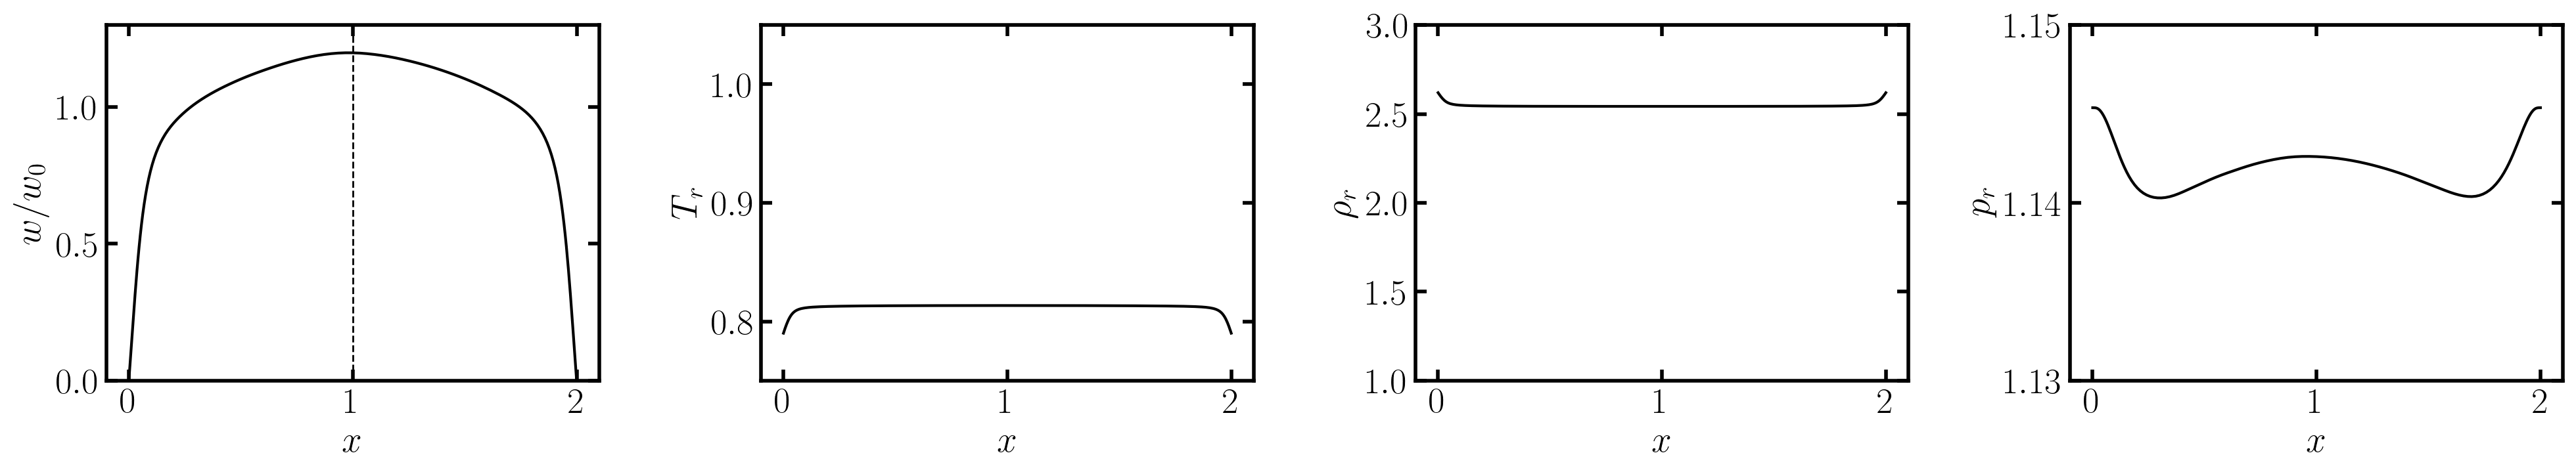

In [3]:
for i, (Tw, (fol, params)) in enumerate(zip(Tw_datasets, datasets), 1):
    ylim = 2e2
    lw = 1.5
    Tref = 0.79
    Rhoref = 2.6191707535
    pr_Zc = 0.3018
    Ec = 4.0000000000e-02
    Cpref = 7.4057624237
    Pfact = pr_Zc/Rhoref/Tref/Ec/Cpref
    w0 = 0.8732

    # --- Debug prints (both walls) ---
    print(f"w_0 = {Tw.w_vol_avg:.6g}")
    print(f"Re_tau wall1 = {Tw.Retauw1:.6g}   wall2 = {Tw.Retauw2:.6g}")
    print(f"y_plus[0] wall1 = {Tw.yplus1[0]:.6g}   wall2 = {Tw.yplus2[-2]:.6g}")
    print(f"Re_tau_star[0] wall1 = {Tw.Retaustar1[0]:.6g}   wall2 = {Tw.Retaustar2[-1]:.6g}")

    # --- Mean velocity profiles, each half normalised by its own utau ---
    Tw.u_plus1 = Tw.w_avg        / Tw.utau1   # bottom half, bottom-wall units
    Tw.u_plus2 = Tw.w_avg[::-1]  / Tw.utau2   # top half, top-wall units (reversed)
    x_wmax = Tw.x[np.argmax(Tw.w_avg)+1]

    # --- Viscous stress, each half ---
    # Bottom half
    duplusdy1       = (1.0 / Tw.utau1) * np.diff(Tw.w_avg) / np.diff(Tw.x)
    visc_y1         = (1.0 / Tw.Retaustar1[:-1]) * duplusdy1
    visc_y1         = np.append(visc_y1, 1e-10)

    # Top half (reversed so index 0 = top wall)
    duplusdy2       = (1.0 / Tw.utau2) * np.diff(Tw.w_avg[::-1]) / np.diff(Tw.x[::-1])
    visc_y2         = (1.0 / Tw.Retaustar2[::-1][:-1]) * duplusdy2
    visc_y2         = np.append(visc_y2, 1e-10)

    # --- Reynolds stresses, normalised per wall ---
    rsxx1 = Tw.rsxx_avg        / Tw.utau1**2
    rsyy1 = Tw.rsyy_avg        / Tw.utau1**2
    rszz1 = Tw.rszz_avg        / Tw.utau1**2
    rsxy1 = Tw.rsxy_avg        / Tw.utau1**2

    rsxx2 = Tw.rsxx_avg[::-1]  / Tw.utau2**2
    rsyy2 = Tw.rsyy_avg[::-1]  / Tw.utau2**2
    rszz2 = Tw.rszz_avg[::-1]  / Tw.utau2**2
    rsxy2 = Tw.rsxy_avg[::-1]  / Tw.utau2**2

    # x-axes for each wall
    yp1 = Tw.yplus1            # bottom wall: 0 → channel centre
    yp2 = Tw.yplus2[::-1]      # top wall:    0 → channel centre
    
    # ------------------------------------------------------------------ #
    fig, ax = plt.subplots(1, 4, figsize=(20, 4))
    ax[0].plot(Tw.x, Tw.w_avg/w0, "-k")

    ax[0].set_ylim(0, 1.3)
    ax[0].axvline(x=x_wmax, color='k', lw=1.0, ls='--', label=r'$w_{max}$')
    ax[0].set_xlabel(r'$x$')
    ax[0].set_ylabel(r'$w/w_0$')
    
    ax[1].plot(Tw.x, Tw.t_avg*Tref, "-k")
    ax[1].set_ylim(0.75, 1.05)
    ax[1].set_xlabel(r'$x$')
    ax[1].set_ylabel(r'$T_r$')
    
    ax[2].plot(Tw.x, Tw.r_avg*Rhoref, "-k")
    ax[2].set_ylim(1.0, 3.0)
    ax[2].set_xlabel(r'$x$')
    ax[2].set_ylabel(r'$\rho_r$')

    ax[3].plot(Tw.x, Tw.p_avg/Pfact, "-k")
    ax[3].set_ylim(1.13, 1.15)
    ax[3].set_xlabel(r'$x$')
    ax[3].set_ylabel(r'$p_r$')
    
    fig.tight_layout()
    plt.show()